In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
from collections import Counter
import scipy.sparse as sp
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patheffects as path_effects
from matplotlib_venn import venn3
import yaml
import time
from itertools import combinations
import gget
from scipy import sparse

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc

# import scvi
# from scvi.external import SysVI

import cupy as cp
import cudf
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator

from cuml.manifold.umap import simplicial_set_embedding
from scanpy.tools._utils import get_init_pos_from_paga 
from cuml.manifold.umap import find_ab_params

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)

cp.cuda.set_allocator(rmm_cupy_allocator)

sc.settings.verbosity = 3

Dataset was downloaded from CellxGene, called 'Skeletal_muscle' from 'Automatic cell-type harmonization and integration across Human Cell Atlas datasets'.

In [2]:
%%time

fpath = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/cellxgene/0116c625-ea28-4b87-836c-201b9f674bf8.h5ad"

adata = sc.read_h5ad(fpath)
sc.logging.print_memory_usage()

adata

Memory usage: current 6.03 GB, difference +6.03 GB
CPU times: user 16.6 s, sys: 2.33 s, total: 19 s
Wall time: 19.5 s


AnnData object with n_obs × n_vars = 201575 × 49787
    obs: 'Dataset', 'donor_id', 'suspension_type', 'Original_annotation', 'CellHint_harmonised_group', 'Curated_annotation', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'is_primary_data', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'exist_in_Micheli2020', 'exist_in_Perez2022', 'exist_in_Tabula2022', 'exist_in_He2020', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'default_embedding', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_umap'

In [3]:
adata.obs.head()

,Dataset,donor_id,suspension_type,Original_annotation,CellHint_harmonised_group,Curated_annotation,assay_ontology_term_id,cell_type_ontology_term_id,development_stage_ontology_term_id,disease_ontology_term_id,...,tissue_type,tissue_ontology_term_id,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
hu_092618_AAACCTGAGGGAACGG,Micheli et al. 2020,hu08_092618,cell,ICAM1+ SELE+ VCAM1+ Endothelial,Group1,Venous endothelial cells,EFO:0009899,CL:0002543,HsapDv:0000148,PATO:0000461,...,tissue,UBERON:0014892,vein endothelial cell,10x 3' v2,normal,male,"skeletal muscle organ, vertebrate",unknown,54-year-old stage,>;{Dt5Emxp
hu_092618_AAACCTGAGGGCTTCC,Micheli et al. 2020,hu08_092618,cell,CLDN5+ PECAM1+ Endothelial,Group15,Capillary endothelial cells,EFO:0009899,CL:0002144,HsapDv:0000148,PATO:0000461,...,tissue,UBERON:0014892,capillary endothelial cell,10x 3' v2,normal,male,"skeletal muscle organ, vertebrate",unknown,54-year-old stage,ek8>X4|4yB
hu_092618_AAACCTGCAAACTGTC,Micheli et al. 2020,hu08_092618,cell,CLDN5+ PECAM1+ Endothelial,Group15,Capillary endothelial cells,EFO:0009899,CL:0002144,HsapDv:0000148,PATO:0000461,...,tissue,UBERON:0014892,capillary endothelial cell,10x 3' v2,normal,male,"skeletal muscle organ, vertebrate",unknown,54-year-old stage,61hrs&FLZ_
hu_092618_AAACCTGCAATGCCAT,Micheli et al. 2020,hu08_092618,cell,CLDN5+ PECAM1+ Endothelial,Group15,Capillary endothelial cells,EFO:0009899,CL:0002144,HsapDv:0000148,PATO:0000461,...,tissue,UBERON:0014892,capillary endothelial cell,10x 3' v2,normal,male,"skeletal muscle organ, vertebrate",unknown,54-year-old stage,)VtR})(e;G
hu_092618_AAACCTGCATAGGATA,Micheli et al. 2020,hu08_092618,cell,CLDN5+ PECAM1+ Endothelial,Group15,Capillary endothelial cells,EFO:0009899,CL:0002144,HsapDv:0000148,PATO:0000461,...,tissue,UBERON:0014892,capillary endothelial cell,10x 3' v2,normal,male,"skeletal muscle organ, vertebrate",unknown,54-year-old stage,gE~K8jhHz3


In [5]:
adata.obs['suspension_type'].value_counts()

suspension_type
nucleus    143051
cell        58524
Name: count, dtype: int64

In [6]:
cell_types = [
    'fast muscle cell', 
    'slow muscle cell', 
    'skeletal muscle satellite stem cell', 
    'cell of skeletal muscle', 
    'fibroblast',
]


adata = adata[adata.obs['cell_type'].isin(cell_types)].copy()

adata

AnnData object with n_obs × n_vars = 135988 × 49787
    obs: 'Dataset', 'donor_id', 'suspension_type', 'Original_annotation', 'CellHint_harmonised_group', 'Curated_annotation', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'is_primary_data', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'exist_in_Micheli2020', 'exist_in_Perez2022', 'exist_in_Tabula2022', 'exist_in_He2020', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'default_embedding', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_umap'

In [7]:
adata.obs['cell_type'].value_counts()

cell_type
fast muscle cell                       64428
slow muscle cell                       44450
skeletal muscle satellite stem cell    13531
fibroblast                              8847
cell of skeletal muscle                 4732
Name: count, dtype: int64

In [8]:
rsc.get.anndata_to_GPU(adata)
rsc.pp.filter_cells(adata, min_counts=200)
rsc.pp.filter_genes(adata, min_counts=50)

adata.layers['counts'] = adata.X.get()

rsc.pp.normalize_total(adata, target_sum=1e4)
rsc.pp.log1p(adata)

adata.layers['log_norm'] = adata.X.get()

rsc.get.anndata_to_CPU(adata) # move to GPU
adata

filtered out 1 cells that have less than 200 counts
filtered out 32485 genes that are detected in less than 50 counts


AnnData object with n_obs × n_vars = 135987 × 17302
    obs: 'Dataset', 'donor_id', 'suspension_type', 'Original_annotation', 'CellHint_harmonised_group', 'Curated_annotation', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'is_primary_data', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_counts', 'n_genes'
    var: 'exist_in_Micheli2020', 'exist_in_Perez2022', 'exist_in_Tabula2022', 'exist_in_He2020', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_counts', 'n_cells'
    uns: 'citation', 'default_embedding', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', 'log_norm'

Number of genes before HVG selection: 17302
Number of genes after HVG selection: 2020


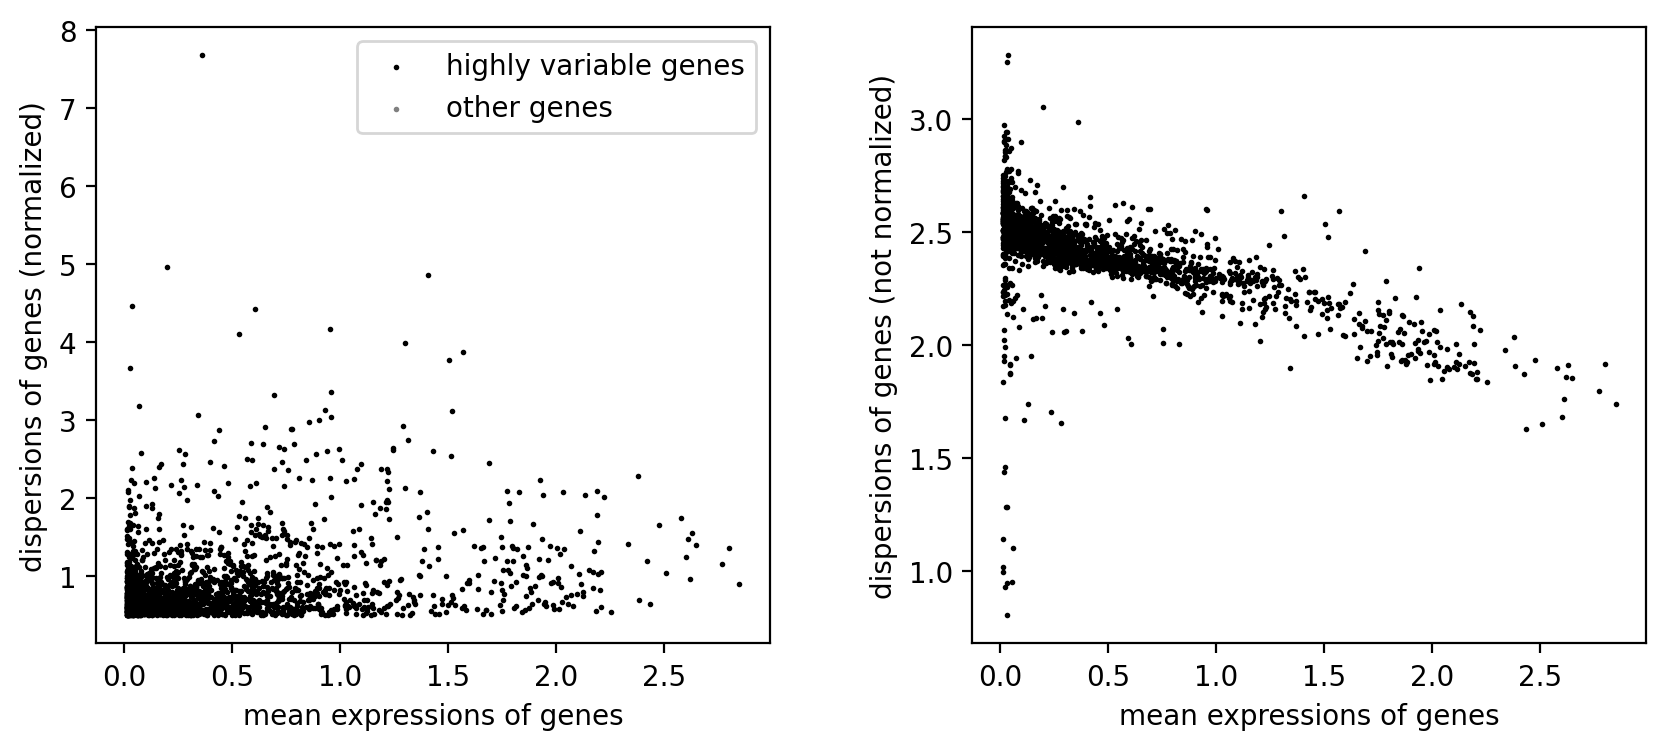

AnnData object with n_obs × n_vars = 135987 × 2020
    obs: 'Dataset', 'donor_id', 'suspension_type', 'Original_annotation', 'CellHint_harmonised_group', 'Curated_annotation', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'is_primary_data', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_counts', 'n_genes'
    var: 'exist_in_Micheli2020', 'exist_in_Perez2022', 'exist_in_Tabula2022', 'exist_in_He2020', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'citation', 'default_embedding', 'organism', 'organism_ontology_ter

In [9]:
adata.raw = adata  # keep full dimension safe
print(f"Number of genes before HVG selection: {adata.n_vars}")

rsc.get.anndata_to_GPU(adata)

rsc.pp.highly_variable_genes(
    adata, 
    batch_key="cell_type",
)

adata = adata[:, adata.var['highly_variable']].copy()

print(f"Number of genes after HVG selection: {adata.n_vars}")

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 4
sc.pl.highly_variable_genes(
    adata
)

adata

computing PCA
    with n_comps=50
    finished (0:00:11)


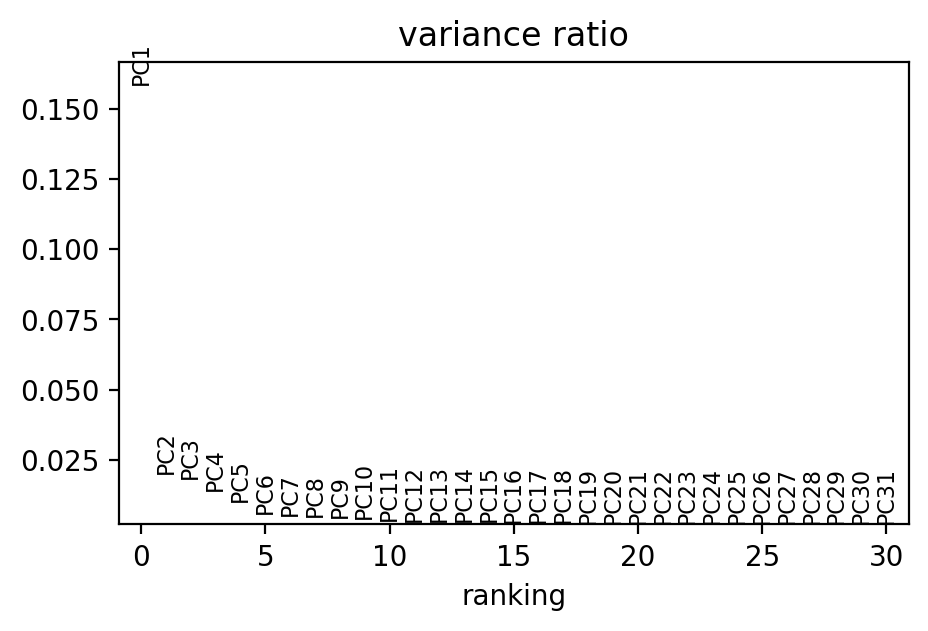

AnnData object with n_obs × n_vars = 135987 × 2020
    obs: 'Dataset', 'donor_id', 'suspension_type', 'Original_annotation', 'CellHint_harmonised_group', 'Curated_annotation', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'is_primary_data', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_counts', 'n_genes'
    var: 'exist_in_Micheli2020', 'exist_in_Perez2022', 'exist_in_Tabula2022', 'exist_in_He2020', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'citation', 'default_embedding', 'organism', 'organism_ontology_ter

In [11]:
rsc.get.anndata_to_CPU(adata)

sc.pp.pca(
    adata,
)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 3
sc.pl.pca_variance_ratio(
    adata
)

adata

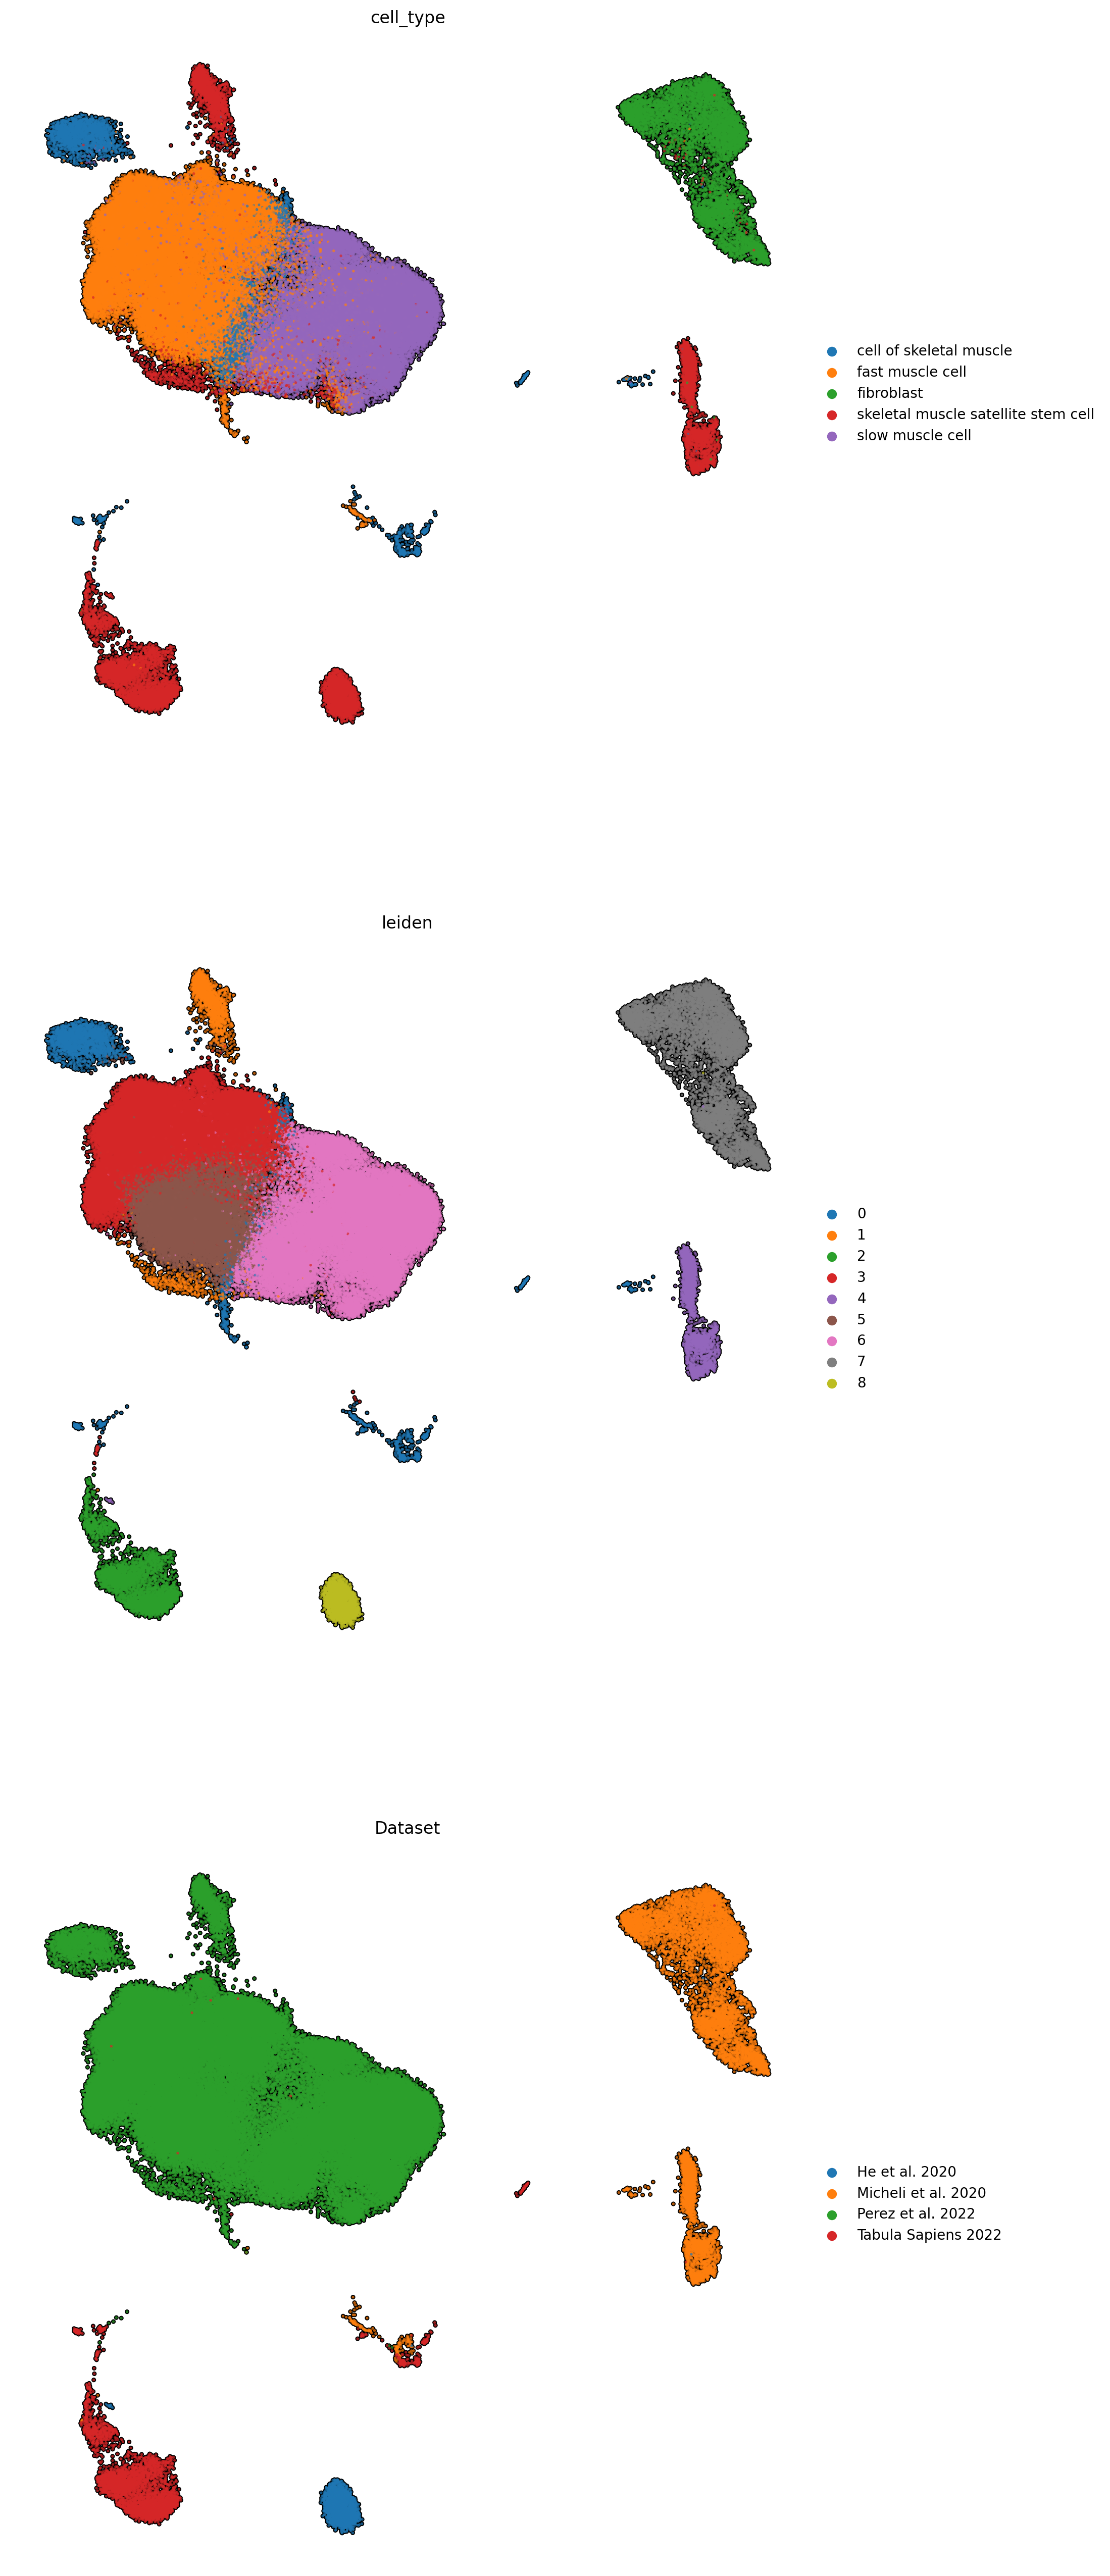

In [13]:
# rsc.get.anndata_to_GPU(adata)

# rsc.pp.neighbors(
#     adata,
# )

# rsc.tl.umap(
#     adata,
# )

# rsc.tl.leiden(
#     adata,
#     resolution=0.35,
# )

# rsc.get.anndata_to_CPU(adata)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 10, 10


sc.pl.umap(
    adata,
    color=['cell_type', 'leiden', 'Dataset'],
    size=15,
    ncols=1,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
)